# Customer Segmentation Analysis

## OIBSIP - Data Analytics
### Level 1 - Task 2

**Objective:**  
Apply customer segmentation techniques to an e-commerce dataset using
RFM (Recency, Frequency, Monetary) analysis and K-Means clustering.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("OnlineRetail.csv", encoding='latin-1')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


In [6]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [11]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [14]:
df.shape

(541909, 8)

In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning

Before performing customer segmentation, the transaction data needs to be
cleaned. Customer IDs are required for customer-level RFM analysis, so
transactions without a CustomerID cannot be assigned to a customer segment.

The dataset also contains cancelled invoices and transactions with zero or
negative quantities/prices. These records are excluded because the objective is
to analyse actual purchasing behaviour.

In [16]:
cancelled_invoices = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Number of cancelled transactions:", len(cancelled_invoices))

Number of cancelled transactions: 9288


In [17]:
cancelled_invoices.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [18]:
print("Negative quantity records:", (df["Quantity"] < 0).sum())

Negative quantity records: 10624


In [19]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [20]:
print("Zero or negative UnitPrice records:", (df["UnitPrice"] <= 0).sum())

Zero or negative UnitPrice records: 2517


In [21]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", len(df_clean))

Rows after removing missing CustomerID: 406829


In [22]:
df_clean["CustomerID"].isnull().sum()

0

In [23]:
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Rows after removing cancelled transactions:", len(df_clean))

Rows after removing cancelled transactions: 397924


In [24]:
df_clean = df_clean[df_clean["Quantity"] > 0]

print("Rows after removing invalid quantities:", len(df_clean))

Rows after removing invalid quantities: 397924


In [25]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Rows after removing invalid prices:", len(df_clean))

Rows after removing invalid prices: 397884


In [26]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [27]:
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)

In [28]:
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

In [29]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 5192


In [30]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 392692


In [31]:
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [32]:
df_clean[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [33]:
print("Final number of rows:", df_clean.shape[0])
print("Final number of columns:", df_clean.shape[1])

Final number of rows: 392692
Final number of columns: 9


In [34]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [35]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [36]:
len(df_clean)

392692

In [37]:
df_clean.shape

(392692, 9)

In [38]:
df_clean.duplicated().sum()

0

In [39]:
df_clean["CustomerID"].nunique()

4338

In [40]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest transaction date:", df_clean["InvoiceDate"].max())
print("Reference date:", reference_date)

Latest transaction date: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


In [41]:
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [42]:
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}, inplace=True)

In [43]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [44]:
print("Number of customers:", rfm.shape[0])
print("Number of RFM features:", rfm.shape[1])

Number of customers: 4338
Number of RFM features: 3


In [45]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346 to 18287
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6+ KB


In [46]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


In [47]:
customer_purchase_value = (
    df_clean.groupby("CustomerID")["TotalAmount"]
    .mean()
    .rename("AveragePurchaseValue")
)

rfm = rfm.join(customer_purchase_value)

In [48]:
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue
CustomerID,,,,
12346,326,1,77183.60,77183.600000
12347,2,7,4310.00,23.681319
12348,75,4,1797.24,57.975484
12349,19,1,1757.55,24.076027
12350,310,1,334.40,19.670588


In [49]:
print(
    "Average purchase value: {:.2f}".format(
        df_clean["TotalAmount"].mean()
    )
)

Average purchase value: 22.63


In [50]:
rfm["CustomerLifetimeValue"] = rfm["Monetary"]

In [51]:
rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "AveragePurchaseValue",
    "CustomerLifetimeValue"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00000,18.000000,51.000,142.00000,374.00
Frequency,4338.0,4.272015,7.697998,1.00000,1.000000,2.000,5.00000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75000,306.482500,668.570,1660.59750,280206.02
AveragePurchaseValue,4338.0,68.381590,1467.918294,2.13697,12.393196,17.755,24.87895,77183.60
CustomerLifetimeValue,4338.0,2048.688081,8985.230220,3.75000,306.482500,668.570,1660.59750,280206.02


In [52]:
print("Missing RFM values:")
print(rfm.isnull().sum())

Missing RFM values:
Recency                  0
Frequency                0
Monetary                 0
AveragePurchaseValue     0
CustomerLifetimeValue    0
dtype: int64


In [53]:
print("Negative RFM values:")
print((rfm[["Recency", "Frequency", "Monetary"]] < 0).sum())

Negative RFM values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [54]:
rfm.to_csv("customer_rfm.csv")

print("RFM dataset saved successfully.")

RFM dataset saved successfully.


In [55]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00000,18.000000,51.000,142.00000,374.00
Frequency,4338.0,4.272015,7.697998,1.00000,1.000000,2.000,5.00000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75000,306.482500,668.570,1660.59750,280206.02
AveragePurchaseValue,4338.0,68.381590,1467.918294,2.13697,12.393196,17.755,24.87895,77183.60
CustomerLifetimeValue,4338.0,2048.688081,8985.230220,3.75000,306.482500,668.570,1660.59750,280206.02


In [56]:
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
CustomerID,,,,,
12346,326,1,77183.60,77183.600000,77183.60
12347,2,7,4310.00,23.681319,4310.00
12348,75,4,1797.24,57.975484,1797.24
12349,19,1,1757.55,24.076027,1757.55
12350,310,1,334.40,19.670588,334.40


## RFM Distribution Analysis

The descriptive statistics show that customer purchasing behaviour varies
considerably.

Recency ranges from 1 to 374 days, while Frequency ranges from 1 to 209
orders. Monetary value ranges from 3.75 to 280,206.02.

The large difference between the mean and median of Monetary value indicates
that a small number of customers contribute a substantial share of total
spending. Similar variation exists in Frequency.

These differences will be examined visually before applying clustering.

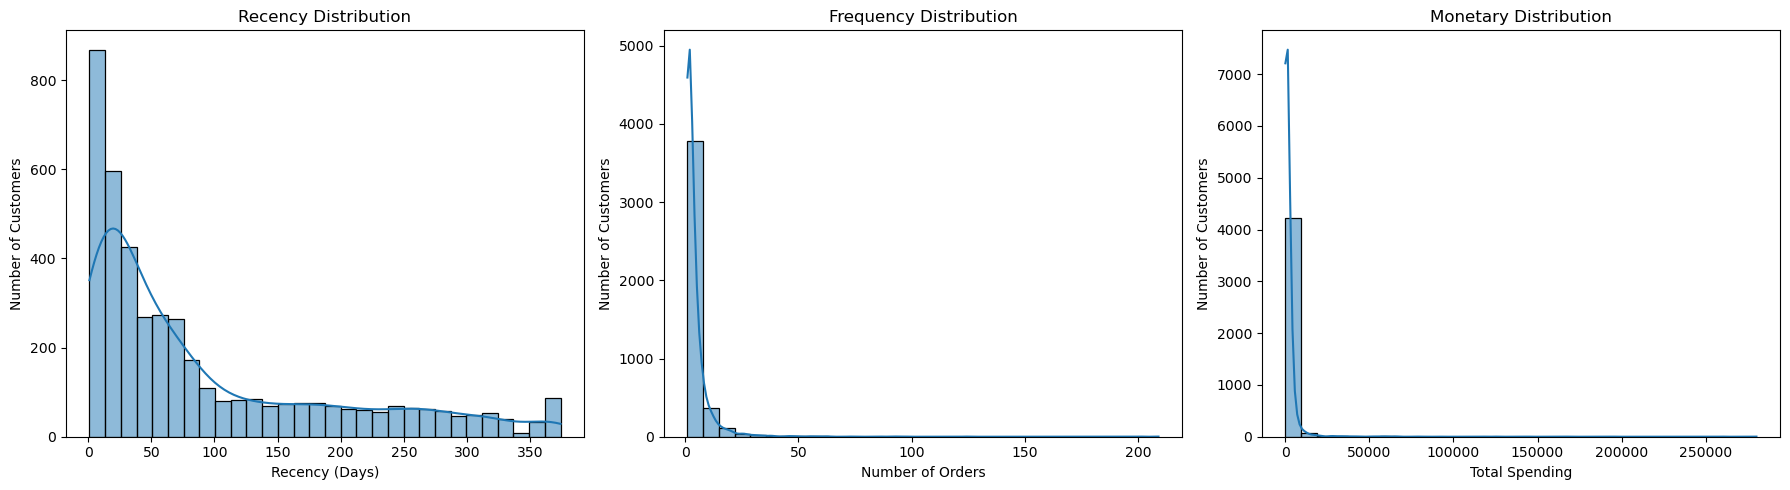

In [57]:
# Plot distributions of RFM features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency (Days)")
axes[0].set_ylabel("Number of Customers")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Customers")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

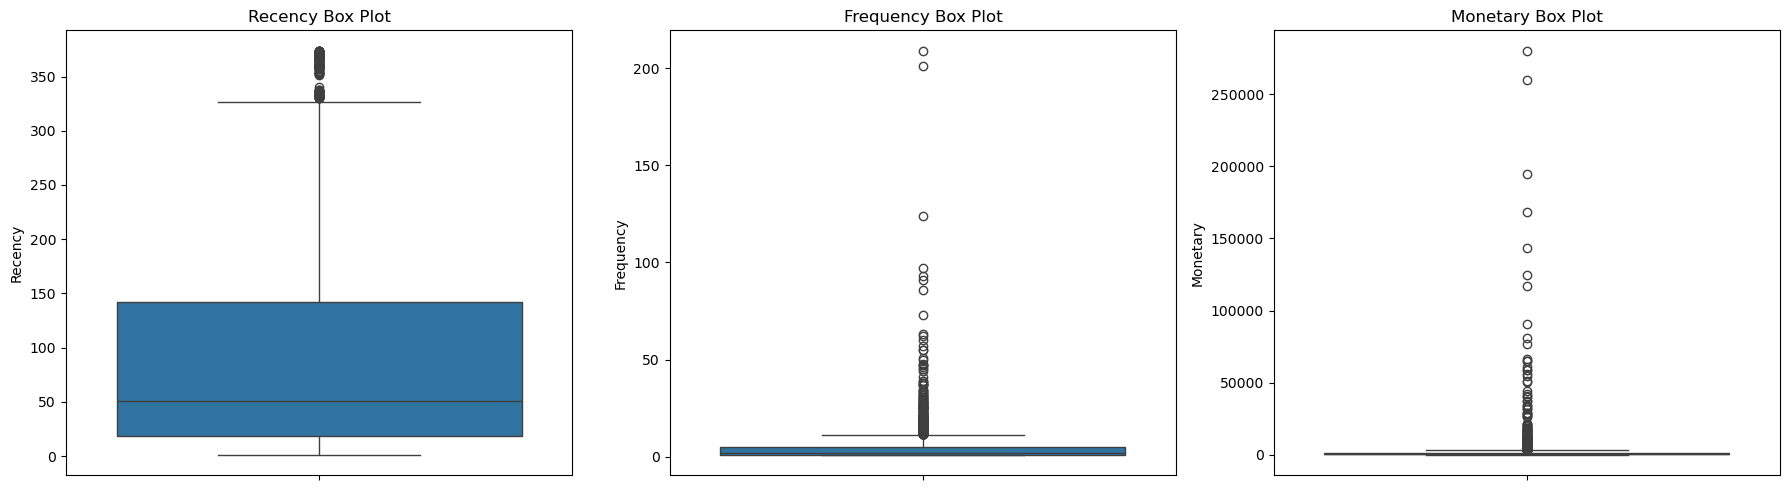

In [58]:
# Box plots for RFM features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency Box Plot")

sns.boxplot(y=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency Box Plot")

sns.boxplot(y=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary Box Plot")

plt.tight_layout()
plt.show()

In [59]:
# Select features for clustering

rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

print("Selected features:")
print(rfm_features.head())

Selected features:
            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


In [60]:
# Standardise RFM features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_features.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.334574,-0.425097,8.363010
12347,-0.905340,0.354417,0.251699
12348,-0.175360,-0.035340,-0.027988
12349,-0.735345,-0.425097,-0.032406
12350,2.174578,-0.425097,-0.190812


In [61]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


In [62]:
# Calculate inertia for different numbers of clusters

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(k_values, inertia):
    print(f"K = {k}: {value:.2f}")

  File "c:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Inertia values:
K = 2: 9014.57
K = 3: 5441.32
K = 4: 4096.30
K = 5: 3119.79
K = 6: 2473.79
K = 7: 2023.59
K = 8: 1717.01
K = 9: 1468.79
K = 10: 1281.05


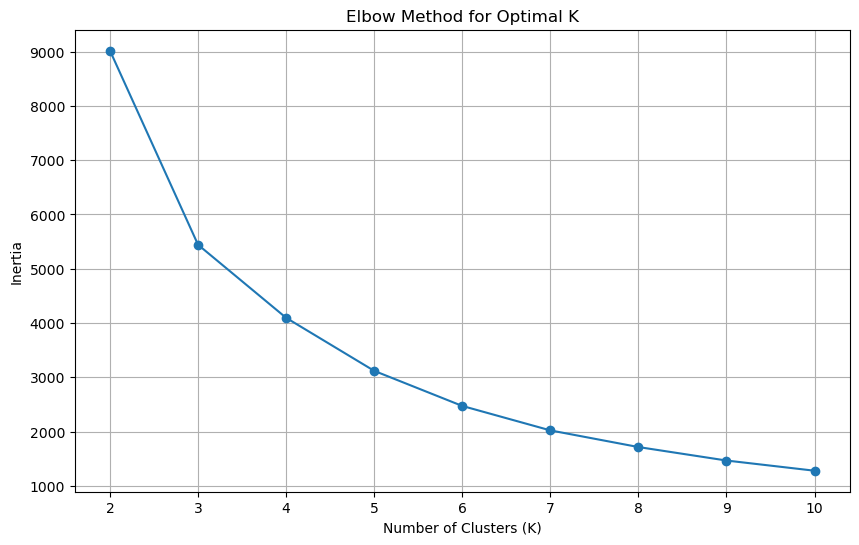

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)

plt.grid(True)
plt.show()

In [64]:
# Set the optimal number of clusters
optimal_k = 5

# Create and fit the K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully.")
print(f"Number of clusters: {optimal_k}")

K-Means clustering completed successfully.
Number of clusters: 5


In [65]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64


In [66]:
# Calculate the average characteristics of each cluster
cluster_profile = (
    rfm.groupby("Cluster")[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "AveragePurchaseValue",
            "CustomerLifetimeValue"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
Cluster,,,,,
0,43.92,3.65,1333.13,30.69,1333.13
1,248.47,1.55,478.65,36.21,478.65
2,6.50,120.50,55099.49,59.10,55099.49
3,15.67,21.29,12813.94,499.56,12813.94
4,7.67,42.83,190808.54,9622.07,190808.54


In [67]:
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].agg(["mean", "min", "max"]).round(2)

cluster_summary

Recency           Frequency            Monetary                      
           mean  min  max      mean min  max       mean        min        max
Cluster                                                                      
0         43.92    1  163      3.65   1   14    1333.13       6.20   13375.87
1        248.47  144  374      1.55   1   12     478.65       3.75    9864.26
2          6.50    1   39    120.50  63  209   55099.49   11189.91  143711.17
3         15.67    1  372     21.29   1   62   12813.94    1296.44   91062.38
4          7.67    1   24     42.83   2   73  190808.54  117210.08  280206.02

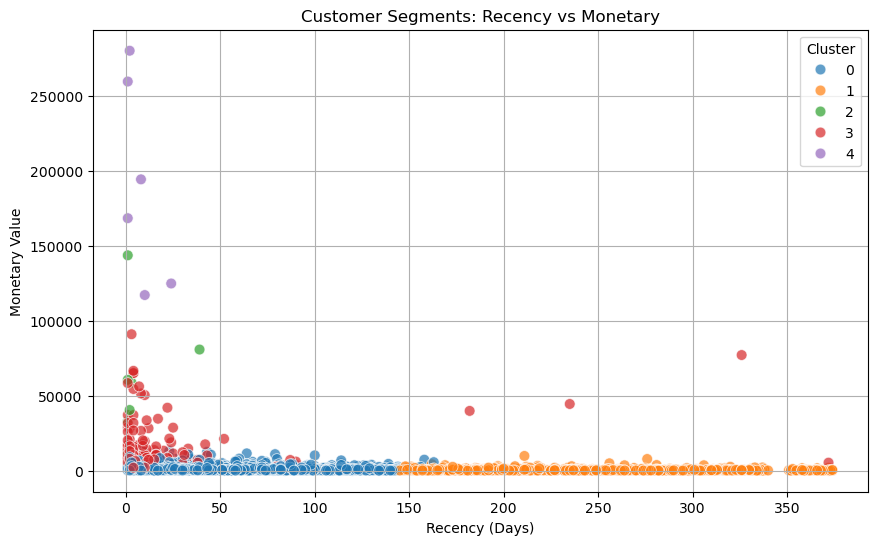

In [68]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=60,
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

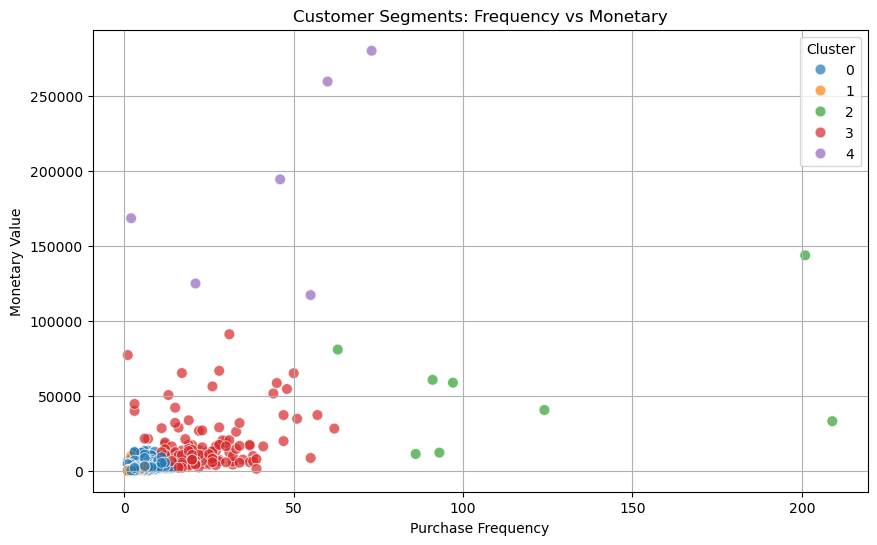

In [69]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=60,
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

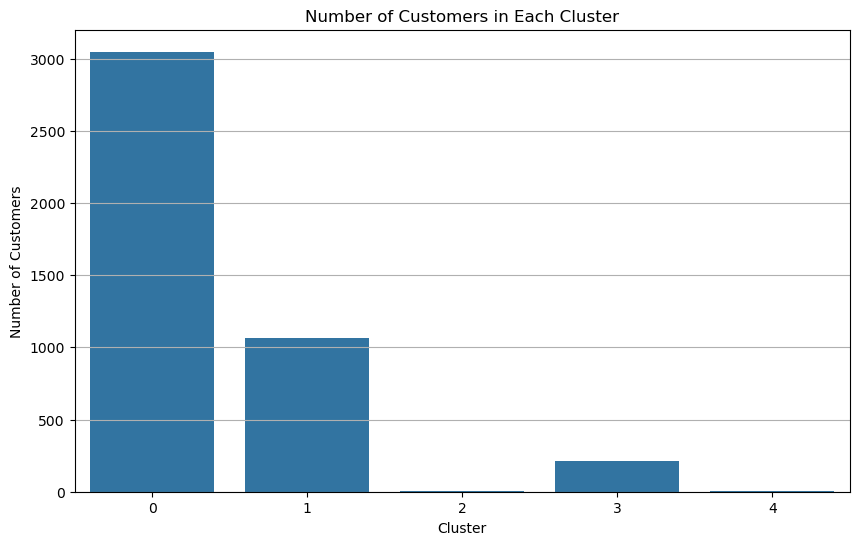

In [70]:
# Count customers in each cluster
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y")
plt.show()

## Exporting the Customer Segmentation Results

The final customer segmentation dataset is exported as a CSV file so that
the results can be reused for further analysis, visualization, or marketing
campaigns.

In [71]:
# Save the final customer segmentation dataset
rfm.to_csv("customer_segments.csv", index=True)

print("Customer segmentation results saved successfully.")
print("File: customer_segments.csv")

Customer segmentation results saved successfully.
File: customer_segments.csv


In [72]:
# Display the final dataset
rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,Cluster
CustomerID,,,,,,
12346,326,1,77183.60,77183.600000,77183.60,3
12347,2,7,4310.00,23.681319,4310.00,0
12348,75,4,1797.24,57.975484,1797.24,0
12349,19,1,1757.55,24.076027,1757.55,0
12350,310,1,334.40,19.670588,334.40,1


In [73]:
print("Final dataset shape:", rfm.shape)
print("\nColumns:")
print(rfm.columns.tolist())

Final dataset shape: (4338, 6)

Columns:
['Recency', 'Frequency', 'Monetary', 'AveragePurchaseValue', 'CustomerLifetimeValue', 'Cluster']
